# Search Model 


In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import DistanceMetric
from sentence_transformers import SentenceTransformer, util

In [74]:
 # Cargamos los datos 
df = pl.read_parquet('data/video-transcripts-3B1B.parquet')
print(df.head())

shape: (5, 5)
┌─────────────┬──────────────────────┬─────────────────────┬─────────────────────┬─────────────────┐
│ video_id    ┆ datetime             ┆ title               ┆ transcript          ┆ datetime_parsed │
│ ---         ┆ ---                  ┆ ---                 ┆ ---                 ┆ ---             │
│ str         ┆ str                  ┆ str                 ┆ str                 ┆ datetime[μs]    │
╞═════════════╪══════════════════════╪═════════════════════╪═════════════════════╪═════════════════╡
│ F_0yfvm0UoU ┆ 2015-03-05T06:15:22Z ┆ e to the pi i, a    ┆ E to the pi i       ┆ 2015-03-05      │
│             ┆                      ┆ nontraditional …    ┆ equals negative on… ┆ 06:15:22        │
│ -9OUyo8NFZg ┆ 2015-06-21T06:05:43Z ┆ Euler&#39;s Formula ┆ In my video on the  ┆ 2015-06-21      │
│             ┆                      ┆ and Graph Du…       ┆ circle divisi…      ┆ 06:05:43        │
│ XFDM1ip5HdU ┆ 2015-08-14T01:20:50Z ┆ What does it feel   ┆ Take 1 plus 2 pl

In [32]:
len(df['transcript'][20])

8238

In [34]:
df['title'][200]

'How to estimate the distance to the sun'

In [75]:
#sorted a polar dataframe by colum 'datatime' 2015-03-05T06:15:22Z
df_sorted = df.with_columns(pl.col("datetime").str.to_datetime()).sort("datetime",descending=True)
print(df_sorted.head())

shape: (5, 5)
┌─────────────┬──────────────────────┬─────────────────────┬─────────────────────┬─────────────────┐
│ video_id    ┆ datetime             ┆ title               ┆ transcript          ┆ datetime_parsed │
│ ---         ┆ ---                  ┆ ---                 ┆ ---                 ┆ ---             │
│ str         ┆ datetime[μs, UTC]    ┆ str                 ┆ str                 ┆ datetime[μs]    │
╞═════════════╪══════════════════════╪═════════════════════╪═════════════════════╪═════════════════╡
│ 3foYyPDp0Ho ┆ 2025-05-05 15:00:08  ┆ Summer of Math      ┆ The time of year    ┆ 2025-05-05      │
│             ┆ UTC                  ┆ Exposition #4 | T…  ┆ has come for th…    ┆ 15:00:08        │
│ Dlsa9EBKDGI ┆ 2025-05-04 11:45:24  ┆ Where my            ┆ Last week I put up  ┆ 2025-05-04      │
│             ┆ UTC                  ┆ explanation of      ┆ a video intro…      ┆ 11:45:24        │
│             ┆                      ┆ Grover’s…           ┆                 

In [76]:
df_clean = df_sorted.with_columns([pl.col("title").str.replace_all("&#39;", "'").alias("title")])

In [78]:
# check the token: &#39; in the column title
title = df_clean.filter(pl.col("transcript").str.contains("&#39;")).get_column("title").to_list()
print(title)

[]


In [20]:
# Filas para hacer el conjunto de validacion 
colums = ['video_id', 'title']

df = df_clean.select(colums).to_pandas()
df.to_csv('data/video-ids-title.txt', sep= ',', index=False, encoding = "utf-8")

(array([89., 45., 36., 22.,  7.,  3.,  3.,  2.,  1.,  5.]),
 array([1.1000e+01, 7.5100e+03, 1.5009e+04, 2.2508e+04, 3.0007e+04,
        3.7506e+04, 4.5005e+04, 5.2504e+04, 6.0003e+04, 6.7502e+04,
        7.5001e+04]),
 <BarContainer object of 10 artists>)

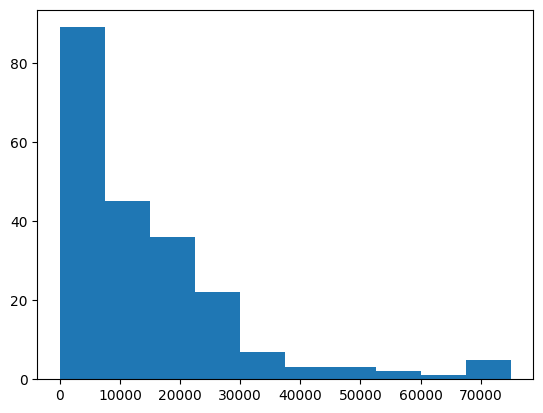

In [18]:
# lengths/character counts
plt.hist(df['transcript'].str.len_chars())

(array([88., 45., 37., 22.,  7.,  3.,  3.,  2.,  1.,  5.]),
 array([1.1000e+01, 7.5100e+03, 1.5009e+04, 2.2508e+04, 3.0007e+04,
        3.7506e+04, 4.5005e+04, 5.2504e+04, 6.0003e+04, 6.7502e+04,
        7.5001e+04]),
 <BarContainer object of 10 artists>)

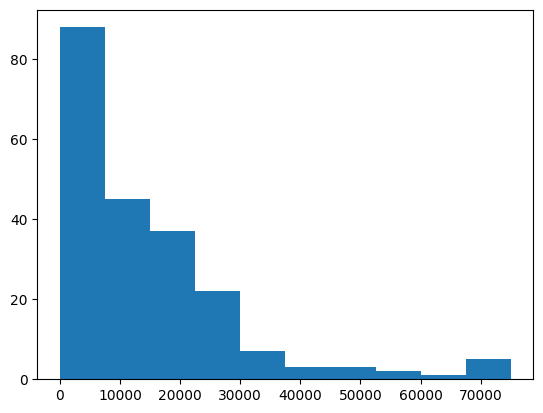

In [4]:
plt.hist(df['transcript'].str.len_chars())

In [29]:
print(df['title'][0:5])
# print(df['transcript'][10])

shape: (5,)
Series: 'title' [str]
[
	"Summer of Math…
	"Where my expla…
	"But what is qu…
	"Testing your i…
	"How to measure…
]


special_strings = ['&#39;', '&amp;', 'sha ']

## Modelo


models are 

In [42]:
df =pl.read_parquet('data/video-transcripts-3B1B.parquet')
print(df.head())
print(df.shape)

shape: (5, 5)
┌─────────────┬──────────────────────┬─────────────────────┬─────────────────────┬─────────────────┐
│ video_id    ┆ datetime             ┆ title               ┆ transcript          ┆ datetime_parsed │
│ ---         ┆ ---                  ┆ ---                 ┆ ---                 ┆ ---             │
│ str         ┆ str                  ┆ str                 ┆ str                 ┆ datetime[μs]    │
╞═════════════╪══════════════════════╪═════════════════════╪═════════════════════╪═════════════════╡
│ F_0yfvm0UoU ┆ 2015-03-05T06:15:22Z ┆ e to the pi i, a    ┆ E to the pi i       ┆ 2015-03-05      │
│             ┆                      ┆ nontraditional …    ┆ equals negative on… ┆ 06:15:22        │
│ -9OUyo8NFZg ┆ 2015-06-21T06:05:43Z ┆ Euler&#39;s Formula ┆ In my video on the  ┆ 2015-06-21      │
│             ┆                      ┆ and Graph Du…       ┆ circle divisi…      ┆ 06:05:43        │
│ XFDM1ip5HdU ┆ 2015-08-14T01:20:50Z ┆ What does it feel   ┆ Take 1 plus 2 pl

In [29]:
cols = ['transcript', 'title']
model_names  = ['all-MiniLM-L6-v2', 'multi-qa-distilbert-cos-v1', 'multi-qa-mpnet-base-dot-v1']

In [39]:
import time 

In [30]:
embedding_dict = {}

for model_name in model_names: 
    model = SentenceTransformer(model_name)

    for col in cols: 
        
        key_name = model_name + '_' + col
        print(key_name) 
        
        embedding_arg = model.encode(df_clean[col].to_list())
        
        embedding_dict[key_name] = embedding_arg

all-MiniLM-L6-v2_transcript
all-MiniLM-L6-v2_title
multi-qa-distilbert-cos-v1_transcript
multi-qa-distilbert-cos-v1_title
multi-qa-mpnet-base-dot-v1_transcript
multi-qa-mpnet-base-dot-v1_title


In [32]:
embedding_dict

{'all-MiniLM-L6-v2_transcript': array([[-0.07952884, -0.02163897,  0.0125359 , ...,  0.02035162,
         -0.08498651,  0.06449372],
        [-0.08989025,  0.06555279, -0.01827063, ..., -0.0054212 ,
         -0.02029522,  0.03200418],
        [-0.11288879, -0.01181222, -0.03281934, ...,  0.01186494,
         -0.02668309, -0.00094035],
        ...,
        [-0.09857002, -0.03710686,  0.04910947, ..., -0.00661583,
         -0.08401316,  0.01039699],
        [-0.08538235,  0.04151753,  0.07437449, ...,  0.0778343 ,
         -0.00183156,  0.01291009],
        [-0.09004877,  0.00132481,  0.02333453, ...,  0.10379487,
          0.04539129, -0.01433767]], dtype=float32),
 'all-MiniLM-L6-v2_title': array([[-0.07265574,  0.02099256,  0.04871921, ...,  0.07220693,
         -0.10165535,  0.04134891],
        [-0.0476203 ,  0.11019435,  0.01701353, ...,  0.03730986,
         -0.02142465,  0.04030941],
        [-0.06631487,  0.07017353, -0.06977472, ...,  0.02842118,
          0.10630818,  0.029486

In [31]:
embedding_dict['multi-qa-mpnet-base-dot-v1_transcript'].shape

(213, 768)

In [22]:
df_eval = pl.read_csv('data/video-ids-title.txt', separator=',', encoding="utf-8")

In [26]:
df_eval = df_eval.filter(pl.col("query").is_not_null()).select(['video_id', 'query'])
df_eval

video_id,query
str,str
"""3foYyPDp0Ho""","""How to learn h…"
"""Dlsa9EBKDGI""","""quantum algori…"
"""RQWpF2Gb-gU""","""quantum comput…"
"""XX8mjBXBqz8""",""" quantum compu…"
"""aQwEJKWATlE""","""distances betw…"
…,…
"""zwAD6dRSVyI""","""understanding …"
"""3s7h2MHQtxc""","""the connection…"
"""S9JGmA5_unY""","""cryptography"""


In [34]:

#embedding query 
query_dict = {}

for model_name in model_names:
    model = SentenceTransformer(model_name)
    key_name = model_name
    q_arg = model.encode(df_eval['query'].to_list())
    query_dict[key_name] = q_arg

In [35]:
query_dict

{'all-MiniLM-L6-v2': array([[ 0.06143483, -0.08337317, -0.02671453, ...,  0.04640081,
         -0.03117071,  0.00588733],
        [-0.10349604,  0.04658411, -0.02025179, ...,  0.02904143,
         -0.00346025,  0.01025082],
        [-0.09277416,  0.00345294, -0.04560607, ...,  0.02503459,
         -0.00157981,  0.01852224],
        ...,
        [-0.03069983,  0.07370888, -0.04900049, ...,  0.04987852,
          0.02884693, -0.04329725],
        [-0.03587146,  0.03546689, -0.08197451, ..., -0.04349765,
          0.03624948, -0.00557988],
        [-0.02259782,  0.069053  , -0.07522328, ..., -0.02739405,
          0.07502814, -0.00558601]], dtype=float32),
 'multi-qa-distilbert-cos-v1': array([[ 0.0196995 ,  0.01436034,  0.02081479, ..., -0.02512378,
          0.02552552,  0.0165314 ],
        [ 0.02541776,  0.01204091, -0.03058895, ..., -0.00092599,
          0.02748305, -0.01710127],
        [-0.02729846, -0.00686532, -0.01927777, ...,  0.01501485,
          0.01572905, -0.0361436 ],
  

In [49]:
distance_names = ['euclidean','manhattan','chebyshev']
sim_names = ['dot_score', 'cos_sim']

In [50]:
query_dict[model_name].shape

(167, 768)

In [39]:
def returnVideoID_index(df: pl.dataframe.frame.DataFrame, df_eval: pl.dataframe.frame.DataFrame, query_n: int) -> int:
    """
        Function to return the index of a dataframe corresponding to the nth row in evaluation dataframe
    """

    return [i for i in range(len(df)) if df['video_id'][i]==df_eval['video_id'][query_n]][0]



def evalTrueRankings(dist_arr_isorted: np.ndarray, df: pl.dataframe.frame.DataFrame, df_eval: pl.dataframe.frame.DataFrame) -> np.ndarray:
    """
        Function to return "true" video ID rankings for each evaluation query
    """
    
    # intialize array to store rankings of "correct" search result
    true_rank_arr = np.empty((1, dist_arr_isorted.shape[1]))
    
    # evaluate ranking of correct result for each query
    for query_n in range(dist_arr_isorted.shape[1]):
    
        # return "true" video ID's in df
        video_id_idx = returnVideoID_index(df, df_eval, query_n)
        
        # evaluate the ranking of the "true" video ID
        true_rank = np.argwhere(dist_arr_isorted[:,query_n]==video_id_idx)[0][0]
        
        # store the "true" video ID's ranking in array
        true_rank_arr[0,query_n] = true_rank

    return true_rank_arr



In [51]:
from sklearn.metrics import DistanceMetric


results = []
for model_name in model_names:
    query_embedding = query_dict[model_name]

    for col in cols:
        embedding_arg = embedding_dict[model_name + '_' + col]

        for dist_name in distance_names:
            dist = DistanceMetric.get_metric(dist_name)
            dist_arg = dist.pairwise(embedding_arg, query_embedding)

            dist_arg_sorted = np.argsort(dist_arg, axis=0)

            method_name = "_".join([model_name,col,dist_name])

            true_ranking_arg = evalTrueRankings(dist_arg_sorted, df_clean, df_eval)

            eval_list = [method_name] + true_ranking_arg.tolist()[0]
            results.append(eval_list)

        for sim_name in sim_names:
             
             cmd = "dist_arg = -util." + sim_name + "(embedding_arg, query_embedding)"
             exec(cmd)

             dist_arr_isorted = np.argsort(dist_arg, axis=0)

             method_name = "_".join([model_name, col, sim_name.replace('_', '-')])
             true_ranking_arg = evalTrueRankings(dist_arr_isorted, df_clean, df_eval)

             eval_list = [method_name] + true_ranking_arg.tolist()[0]
             results.append(eval_list)



    

In [54]:
len(results)

30

In [55]:
for model_name in model_names:
    
    # generate embeddings
    embedding_arr1 = embedding_dict[model_name+'_title']
    embedding_arr2 = embedding_dict[model_name+'_transcript']
    query_embedding = query_dict[model_name]

    for dist_name in distance_names:

        # compute distance between video text and query
        dist = DistanceMetric.get_metric(dist_name)
        dist_arr = dist.pairwise(embedding_arr1, query_embedding) + dist.pairwise(embedding_arr2, query_embedding)

        # sort indexes of distance array
        dist_arr_isorted = np.argsort(dist_arr, axis=0)

         # define label for search method
        method_name = "_".join([model_name, "title-transcript", dist_name])

        # evaluate the ranking of the ground truth
        true_rank_arr = evalTrueRankings(dist_arr_isorted, df_clean, df_eval)

        # store results
        eval_list = [method_name] + true_rank_arr.tolist()[0]
        results.append(eval_list)

    # loop through sbert similarity scores
    for sim_name in sim_names:
        # apply similarity score from sbert
        cmd = "dist_arr = -util." + sim_name + "(embedding_arr1, query_embedding) - util."+ sim_name + "(embedding_arr2, query_embedding)"
        exec(cmd)

        # sort indexes of distance array (notice minus sign in front of cosine similarity)
        dist_arr_isorted = np.argsort(dist_arr, axis=0)

        # define label for search method
        method_name = "_".join([model_name, "title-transcript", sim_name.replace("_","-")])

        # evaluate the ranking of the ground truth
        true_rank_arr = evalTrueRankings(dist_arr_isorted, df_clean, df_eval)

        # store results
        eval_list = [method_name] + true_rank_arr.tolist()[0]
        results.append(eval_list)

In [56]:
len(results)

45

In [59]:
schema_dict = {'method_name':str}
for i in range(len(results[0])-1):
    schema_dict['rank_query-'+str(i)] = float

df_results = pl.DataFrame(results, schema=schema_dict)
df_results

method_name,rank_query-0,rank_query-1,rank_query-2,rank_query-3,rank_query-4,rank_query-5,rank_query-6,rank_query-7,rank_query-8,rank_query-9,rank_query-10,rank_query-11,rank_query-12,rank_query-13,rank_query-14,rank_query-15,rank_query-16,rank_query-17,rank_query-18,rank_query-19,rank_query-20,rank_query-21,rank_query-22,rank_query-23,rank_query-24,rank_query-25,rank_query-26,rank_query-27,rank_query-28,rank_query-29,rank_query-30,rank_query-31,rank_query-32,rank_query-33,rank_query-34,rank_query-35,…,rank_query-130,rank_query-131,rank_query-132,rank_query-133,rank_query-134,rank_query-135,rank_query-136,rank_query-137,rank_query-138,rank_query-139,rank_query-140,rank_query-141,rank_query-142,rank_query-143,rank_query-144,rank_query-145,rank_query-146,rank_query-147,rank_query-148,rank_query-149,rank_query-150,rank_query-151,rank_query-152,rank_query-153,rank_query-154,rank_query-155,rank_query-156,rank_query-157,rank_query-158,rank_query-159,rank_query-160,rank_query-161,rank_query-162,rank_query-163,rank_query-164,rank_query-165,rank_query-166
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""all-MiniLM-L6-…",3.0,0.0,0.0,5.0,1.0,0.0,0.0,0.0,14.0,5.0,0.0,2.0,0.0,6.0,0.0,3.0,10.0,13.0,1.0,0.0,9.0,5.0,8.0,10.0,7.0,108.0,7.0,47.0,3.0,0.0,15.0,4.0,1.0,0.0,1.0,0.0,…,10.0,103.0,39.0,0.0,1.0,0.0,7.0,22.0,128.0,18.0,0.0,14.0,0.0,38.0,1.0,0.0,1.0,9.0,19.0,0.0,0.0,2.0,0.0,0.0,21.0,20.0,0.0,2.0,1.0,4.0,8.0,0.0,25.0,0.0,0.0,0.0,0.0
"""all-MiniLM-L6-…",4.0,0.0,0.0,5.0,1.0,0.0,0.0,0.0,15.0,5.0,0.0,2.0,0.0,5.0,0.0,3.0,10.0,11.0,1.0,0.0,9.0,8.0,16.0,11.0,3.0,80.0,2.0,54.0,2.0,0.0,19.0,4.0,1.0,0.0,1.0,0.0,…,10.0,165.0,53.0,0.0,1.0,0.0,9.0,31.0,123.0,31.0,0.0,14.0,0.0,79.0,1.0,2.0,1.0,11.0,14.0,0.0,0.0,3.0,0.0,0.0,33.0,17.0,0.0,2.0,1.0,3.0,7.0,0.0,35.0,0.0,0.0,0.0,0.0
"""all-MiniLM-L6-…",141.0,0.0,0.0,53.0,2.0,0.0,0.0,3.0,20.0,33.0,0.0,3.0,0.0,26.0,2.0,8.0,88.0,26.0,0.0,49.0,27.0,12.0,76.0,99.0,97.0,166.0,20.0,54.0,22.0,1.0,57.0,60.0,141.0,82.0,0.0,6.0,…,8.0,100.0,126.0,0.0,12.0,0.0,51.0,22.0,124.0,108.0,0.0,37.0,11.0,105.0,0.0,11.0,34.0,66.0,128.0,0.0,19.0,100.0,32.0,0.0,10.0,153.0,0.0,2.0,0.0,32.0,115.0,0.0,15.0,3.0,0.0,94.0,0.0
"""all-MiniLM-L6-…",3.0,0.0,0.0,5.0,1.0,0.0,0.0,0.0,14.0,5.0,0.0,2.0,0.0,6.0,0.0,3.0,10.0,13.0,1.0,0.0,9.0,5.0,8.0,10.0,7.0,108.0,7.0,47.0,3.0,0.0,15.0,4.0,1.0,0.0,1.0,0.0,…,10.0,103.0,39.0,0.0,1.0,0.0,7.0,22.0,128.0,18.0,0.0,14.0,0.0,38.0,1.0,0.0,1.0,9.0,19.0,0.0,0.0,2.0,0.0,0.0,21.0,20.0,0.0,2.0,1.0,4.0,8.0,0.0,25.0,0.0,0.0,0.0,0.0
"""all-MiniLM-L6-…",3.0,0.0,0.0,5.0,1.0,0.0,0.0,0.0,14.0,5.0,0.0,2.0,0.0,6.0,0.0,3.0,10.0,13.0,1.0,0.0,9.0,5.0,8.0,10.0,7.0,108.0,7.0,47.0,3.0,0.0,15.0,4.0,1.0,0.0,1.0,0.0,…,10.0,103.0,39.0,0.0,1.0,0.0,7.0,22.0,128.0,18.0,0.0,14.0,0.0,38.0,1.0,0.0,1.0,9.0,19.0,0.0,0.0,2.0,0.0,0.0,21.0,20.0,0.0,2.0,1.0,4.0,8.0,0.0,25.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""multi-qa-mpnet…",17.0,3.0,0.0,1.0,1.0,2.0,0.0,2.0,16.0,48.0,0.0,0.0,0.0,0.0,5.0,3.0,2.0,53.0,0.0,37.0,9.0,0.0,1.0,69.0,0.0,44.0,5.0,10.0,0.0,0.0,18.0,1.0,0.0,1.0,0.0,1.0,…,8.0,2.0,1.0,0.0,0.0,0.0,17.0,29.0,50.0,4.0,0.0,0.0,0.0,43.0,1.0,26.0,0.0,3.0,6.0,31.0,1.0,4.0,0.0,0.0,10.0,0.0,0.0,22.0,2.0,1.0,0.0,0.0,21.0,1.0,1.0,0.0,0.0
"""multi-qa-mpnet…",26.0,3.0,1.0,0.0,1.0,2.0,0.0,2.0,15.0,54.0,0.0,0.0,0.0,0.0,5.0,3.0,2.0,43.0,0.0,36.0,7.0,0.0,1.0,70.0,0.0,51.0,2.0,9.0,0.0,0.0,12.0,3.0,0.0,1.0,0.0,1.0,…,9.0,2.0,1.0,0.0,0.0,0.0,17.0,31.0,51.0,7.0,0.0,0.0,0.0,61.0,1.0,36.0,0.0,3.0,6.0,41.0,1.0,4.0,0.0,0.0,10.0,0.0,0.0,21.0,2.0,1.0,0.0,0.0,23.0,0.0,2.0,0.0,0.0
"""multi-qa-mpnet…",32.0,19.0,1.0,0.0,1.0,3.0,44.0,1.0,152.0,102.0,0.0,0.0,0.0,1.0,0.0,6.0,3.0,194.0,0.0,182.0,

In [60]:
df_results = df_results.with_columns(new_col=pl.mean_horizontal(df_results.columns[1:])).rename({"new_col": "rank_query-mean"})

In [61]:
for i in [1,3]:
    df_results = df_results.with_columns(new_col=pl.sum_horizontal(df_results[:,1:-1]<i)).rename({"new_col": "num_in_top-"+str(i)})

In [62]:
df_summary = df_results[['method_name', "rank_query-mean", "num_in_top-1", "num_in_top-3"]]

In [63]:
print(df_summary.sort('rank_query-mean').head())

shape: (5, 4)
┌───────────────────────────────────┬─────────────────┬──────────────┬──────────────┐
│ method_name                       ┆ rank_query-mean ┆ num_in_top-1 ┆ num_in_top-3 │
│ ---                               ┆ ---             ┆ ---          ┆ ---          │
│ str                               ┆ f64             ┆ u32          ┆ u32          │
╞═══════════════════════════════════╪═════════════════╪══════════════╪══════════════╡
│ multi-qa-mpnet-base-dot-v1_title… ┆ 8.311377        ┆ 65           ┆ 102          │
│ multi-qa-distilbert-cos-v1_title… ┆ 8.437126        ┆ 62           ┆ 105          │
│ multi-qa-mpnet-base-dot-v1_title… ┆ 8.598802        ┆ 65           ┆ 105          │
│ multi-qa-distilbert-cos-v1_title… ┆ 8.652695        ┆ 63           ┆ 104          │
│ all-MiniLM-L6-v2_title-transcrip… ┆ 8.730539        ┆ 58           ┆ 102          │
└───────────────────────────────────┴─────────────────┴──────────────┴──────────────┘


In [64]:
df_summary.sort('rank_query-mean').head()[0,0]

'multi-qa-mpnet-base-dot-v1_title-transcript_dot-score'

In [65]:
print(df_summary.sort("num_in_top-1", descending=True).head())

shape: (5, 4)
┌───────────────────────────────────┬─────────────────┬──────────────┬──────────────┐
│ method_name                       ┆ rank_query-mean ┆ num_in_top-1 ┆ num_in_top-3 │
│ ---                               ┆ ---             ┆ ---          ┆ ---          │
│ str                               ┆ f64             ┆ u32          ┆ u32          │
╞═══════════════════════════════════╪═════════════════╪══════════════╪══════════════╡
│ multi-qa-mpnet-base-dot-v1_title… ┆ 8.311377        ┆ 65           ┆ 102          │
│ multi-qa-mpnet-base-dot-v1_title… ┆ 8.598802        ┆ 65           ┆ 105          │
│ all-MiniLM-L6-v2_title_euclidean  ┆ 14.748503       ┆ 64           ┆ 101          │
│ all-MiniLM-L6-v2_title_dot-score  ┆ 14.748503       ┆ 64           ┆ 101          │
│ all-MiniLM-L6-v2_title_cos-sim    ┆ 14.748503       ┆ 64           ┆ 101          │
└───────────────────────────────────┴─────────────────┴──────────────┴──────────────┘


In [69]:
df_summary.sort('num_in_top-1', descending=True).head()[0,0]

'multi-qa-mpnet-base-dot-v1_title-transcript_dot-score'

In [66]:
print(df_summary.sort("num_in_top-3", descending=True).head())

shape: (5, 4)
┌───────────────────────────────────┬─────────────────┬──────────────┬──────────────┐
│ method_name                       ┆ rank_query-mean ┆ num_in_top-1 ┆ num_in_top-3 │
│ ---                               ┆ ---             ┆ ---          ┆ ---          │
│ str                               ┆ f64             ┆ u32          ┆ u32          │
╞═══════════════════════════════════╪═════════════════╪══════════════╪══════════════╡
│ multi-qa-distilbert-cos-v1_title… ┆ 8.437126        ┆ 62           ┆ 105          │
│ multi-qa-mpnet-base-dot-v1_title… ┆ 11.035928       ┆ 62           ┆ 105          │
│ multi-qa-mpnet-base-dot-v1_title… ┆ 8.598802        ┆ 65           ┆ 105          │
│ multi-qa-distilbert-cos-v1_title… ┆ 8.652695        ┆ 63           ┆ 104          │
│ multi-qa-distilbert-cos-v1_title… ┆ 8.760479        ┆ 59           ┆ 104          │
└───────────────────────────────────┴─────────────────┴──────────────┴──────────────┘


In [67]:
df_summary.sort("num_in_top-3", descending=True).head()[0,0]

'multi-qa-distilbert-cos-v1_title-transcript_manhattan'

In [68]:
for i in range(4):
    print(df_summary.sort("num_in_top-3", descending=True)['method_name'][i])



multi-qa-distilbert-cos-v1_title-transcript_manhattan
multi-qa-mpnet-base-dot-v1_title-transcript_euclidean
multi-qa-mpnet-base-dot-v1_title-transcript_cos-sim
multi-qa-distilbert-cos-v1_title-transcript_euclidean


In [80]:

model_name_final = 'multi-qa-mpnet-base-dot-v1'

model = SentenceTransformer(model_name)

for column_name in cols:
    embedding_arr = model.encode(df_clean[column_name].to_list())
    schema_dict = {column_name+'_embedding-'+str(i): float for i in range(embedding_arr.shape[1])}
    df_embedding = pl.DataFrame(embedding_arr, schema=schema_dict)
    df_clean = pl.concat([df_clean, df_embedding], how='horizontal')



CPU times: total: 2min 4s
Wall time: 43.4 s


In [134]:
df_embedding.shape

(213, 768)

In [135]:
df_clean

video_id,datetime,title,transcript,datetime_parsed,transcript_embedding-0,transcript_embedding-1,transcript_embedding-2,transcript_embedding-3,transcript_embedding-4,transcript_embedding-5,transcript_embedding-6,transcript_embedding-7,transcript_embedding-8,transcript_embedding-9,transcript_embedding-10,transcript_embedding-11,transcript_embedding-12,transcript_embedding-13,transcript_embedding-14,transcript_embedding-15,transcript_embedding-16,transcript_embedding-17,transcript_embedding-18,transcript_embedding-19,transcript_embedding-20,transcript_embedding-21,transcript_embedding-22,transcript_embedding-23,transcript_embedding-24,transcript_embedding-25,transcript_embedding-26,transcript_embedding-27,transcript_embedding-28,transcript_embedding-29,transcript_embedding-30,transcript_embedding-31,…,title_embedding-731,title_embedding-732,title_embedding-733,title_embedding-734,title_embedding-735,title_embedding-736,title_embedding-737,title_embedding-738,title_embedding-739,title_embedding-740,title_embedding-741,title_embedding-742,title_embedding-743,title_embedding-744,title_embedding-745,title_embedding-746,title_embedding-747,title_embedding-748,title_embedding-749,title_embedding-750,title_embedding-751,title_embedding-752,title_embedding-753,title_embedding-754,title_embedding-755,title_embedding-756,title_embedding-757,title_embedding-758,title_embedding-759,title_embedding-760,title_embedding-761,title_embedding-762,title_embedding-763,title_embedding-764,title_embedding-765,title_embedding-766,title_embedding-767
str,"datetime[μs, UTC]",str,str,datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""3foYyPDp0Ho""",2025-05-05 15:00:08 UTC,"""Summer of Math…","""The time of ye…",2025-05-05 15:00:08,-0.066961,0.221325,-0.196238,0.313624,-0.139647,-0.312773,-0.113672,-0.10444,-0.176161,0.260139,-0.069984,0.121533,0.112199,-0.00366,0.109204,-0.397972,-0.033471,-0.386925,0.102872,-0.07627,0.196955,-0.262961,0.009243,0.088936,0.057973,0.045155,-0.179302,-0.307321,-0.057867,-0.664589,-0.235711,0.366571,…,-0.2152,-0.301627,0.282506,0.011948,0.128682,0.156913,-0.472205,0.040081,0.009924,-0.045604,-0.120621,0.316814,-0.059792,0.110786,-0.175714,-0.216622,-0.008054,-0.329563,-0.414219,-0.337546,0.205473,0.255863,0.302681,-0.159415,-0.30805,0.159475,-0.088765,-0.187395,0.279193,0.262826,-0.075312,-0.043983,0.040086,-0.066508,0.008599,-0.099008,-0.176777
"""Dlsa9EBKDGI""",2025-05-04 11:45:24 UTC,"""Where my expla…","""Last week I pu…",2025-05-04 11:45:24,0.266738,-0.262616,-0.082066,-0.202538,-0.14576,-0.439285,-0.033466,0.335784,-0.099554,0.598449,0.239078,-0.085203,0.199005,-0.036283,0.184611,-0.020465,0.406809,0.485784,-0.427158,-0.24092,-0.221989,-0.114776,-0.218438,0.178062,0.103497,-0.234416,-0.220418,0.094471,0.026682,0.107422,-0.253735,0.047521,…,0.175441,-0.226441,0.057889,0.228112,-0.099714,0.243667,-0.157664,0.390499,0.053645,0.173772,-0.119725,-0.004574,0.195176,-0.140392,-0.578089,-0.169938,0.25233,-0.166913,-0.36057,-0.325173,0.054275,0.367854,-0.072566,-0.145919,-0.190695,0.037926,-0.07628,0.001248,0.277684,0.033728,0.285203,0.017581,0.298525,0.061211,0.077548,-0.121436,-0.29448
"""RQWpF2Gb-gU""",2025-04-30 12:32:19 UTC,"""But what is qu…","""A lot of pop s…",2025-04-30 12:32:19,-0.219667,-0.14819,-0.147609,0.068073,-0.202293,-0.010669,0.074758,0.080694,0.037911,0.2428,0.286179,-0.509888,0.195256,0.049335,-0.022305,-0.200406,0.366113,0.333585,-0.389359,-0.117643,-0.277408,-0.208404,-0.24308,-0.028625,0.240257,-0.335284,-0.010892,0.026498,0.073219,-0.219159,-0.454633,0.000122,…,-0.057416,-0.024893,0.386913,0.272836,-0.212985,0.149268,-0.156346,-0.04475,0.042349,0.086109,0.230264,0.031912,0.024947,0.003024,-0.335558,-0.027093,0.095899,-0.029857,-0.003839,-0.408425,0.053119,-0.068808

In [115]:
df_clean.write_parquet('data/video-index-final.parquet')

In [127]:
import gradio as gr 

df = pl.scan_parquet('data/video-index-final.parquet')

model_name_final = 'multi-qa-mpnet-base-dot-v1'
distance = 'manhattan'


In [151]:
df = pl.read_parquet("data/video-index-final.parquet") 

def returnSearchResults(query: str,index: pl.DataFrame,top_k: int = 5,threshold: float | None = None,) -> np.ndarray:
    """
    Retorna los índices de los `top_k` vídeos más cercanos a *query*.
    Si se define `threshold`, primero filtra distancias < threshold.
    """
    query_emb = model.encode([query]).reshape(1, -1)

    cols = index.columns
    emb_title = index.select(cols[5:773]).to_numpy()    
    emb_trans = index.select(cols[773:]).to_numpy()      

    dist_arr = ( dist.pairwise(emb_title, query_emb) + dist.pairwise(emb_trans, query_emb) ).flatten()                                          

    if threshold is not None:
        idx = np.where(dist_arr < threshold)[0]
        if idx.size == 0:
            return np.array([], dtype=int)
        idx_sorted = idx[np.argsort(dist_arr[idx])]
    else:
        idx_sorted = np.argsort(dist_arr)
    return idx_sorted[:top_k]

In [160]:
# query      = "deep learning"
query = "neural networks"
idx_result = returnSearchResults(query, df)

print(df.select(["video_id", "title"]).to_pandas().iloc[idx_result])


        video_id                                              title
162  aircAruvnKk  But what is a neural network? | Deep learning ...
161  IHZwWFHWa-w  Gradient descent, how neural networks learn | DL2
160  Ilg3gGewQ5U                 Backpropagation, intuitively | DL3
159  tIeHLnjs5U8                     Backpropagation calculus | DL4
157  liL66CApESk                 Q&amp;A #2 + Net Neutrality Nuance


In [169]:
# print(pl.DataFrame(df.select(["title", "video_id"])).take(idx_result).to_dict(as_series=False))
print(df.select(["title", "video_id"])[idx_result].to_dict(as_series=False))

{'title': ['But what is a neural network? | Deep learning chapter 1', 'Gradient descent, how neural networks learn | DL2', 'Backpropagation, intuitively | DL3', 'Backpropagation calculus | DL4', 'Q&amp;A #2 + Net Neutrality Nuance'], 'video_id': ['aircAruvnKk', 'IHZwWFHWa-w', 'Ilg3gGewQ5U', 'tIeHLnjs5U8', 'liL66CApESk']}


In [170]:


def pseudoSearchAPI(query: str):
    
    # return top 5 search results
    idx_result = returnSearchResults(query, df)
    response = df.select(["title", "video_id"])[idx_result].to_dict(as_series=False)

    return response



def formatResultText(title: str, video_id: str):
    
    text = markdown_text = f"""<br> <br>
# {title}<br>

🔗 [Video Link](https://youtu.be/{video_id})"""

    return text


def formatVideoEmbed(video_id: str):

    # other options
    # embed = '<iframe width="640" height="360" src="https://img.youtube.com/vi/'+ video_id +'/0.jpg" </iframe>'
    # embed = '<a href="https://youtu.be/'+ video_id +'"> <img src="https://img.youtube.com/vi/'+ video_id +'/0.jpg" style="width:576;height:324;"></a>'
    # embed = '<a href="www.youtube.com/watch?v='+ video_id +'"> <img src="https://img.youtube.com/vi/'+ video_id +'/0.jpg" style="width:576;height:324;"></a>'
    
    return '<iframe width="576" height="324" src="https://www.youtube.com/embed/'+ video_id +'"></iframe>'


def searchResults(query):
    # pseudo API call
    response = pseudoSearchAPI(query)

    # format search results

    # initialize list of outputs
    output_list = []

    # compute number of null search results (out of 5)
    num_empty_results = 5-len(response['title'])

    # display search results
    for i in range(len(response['title'])):
        video_id = response['video_id'][i]
        title = response['title'][i]

        embed = gr.HTML(value = formatVideoEmbed(video_id), visible=True)
        text = gr.Markdown(value = formatResultText(title, video_id), visible=True)

        output_list.append(embed)
        output_list.append(text)

    # make null search result slots invisible
    for i in range(num_empty_results):
        
        # if no search results display "No results." text
        if num_empty_results==5 and i==0:
            embed = gr.HTML(visible=False)
            text = gr.Markdown(value = "No results. Try rephrasing your query.", visible=True)

            output_list.append(embed)
            output_list.append(text)
            continue

        embed = gr.HTML(visible=False)
        text = gr.Markdown(visible=False)

        output_list.append(embed)
        output_list.append(text)
        
    return output_list

In [171]:
output_list = []

with gr.Blocks() as demo:
    gr.Markdown("# YouTube Search")

    with gr.Row():
        inp = gr.Textbox(placeholder="What are you looking for?", label="Query", scale=3)
        btn = gr.Button("Search")
        btn.click(fn=searchResults, inputs=inp, outputs=output_list)
    
    for i in range(5):
        with gr.Row():
            output_list.append(gr.HTML())
            output_list.append(gr.Markdown())
             
    inp.submit(fn=searchResults, inputs=inp, outputs=output_list)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
